# Density based clustering

In this section we perform a density based clustering over our clean merged dataset.

In order to do this, we use the **DBSCAN** algorithm (**Density-Based Spatial Clustering of Applications with Noise**), designed to identify groups of densely packed points while marking isolated observations as noise.

## DBSCAN Algorithm

Instead of relying on predefined cluster shapes or the number of clusters, DBSCAN **classifies data points based on local density**. Each point is assigned to one of three categories:

- **core points**, which have a sufficient number of neighboring points within a specified radius;
- **border points**, which lie close to core points but do not themselves meet the density requirement;
- **noise points**, which do not belong to any dense region.

The behavior of DBSCAN is primarily governed by two parameters:

- **$\epsilon$**, which defines the maximum distance between two points to be considered neighbors;
- **MinPts**, the minimum number of points required to form a dense region.

Tuning these parameters is essential, as they directly influence cluster shapes, the identification of noise, and the algorithm’s overall sensitivity to data distribution.

DBSCAN offers several _strengths_: it can discover clusters of arbitrary shapes, is robust to outliers, and does not require the number of clusters to be specified beforehand.

However, it also presents some _limitations_; its performance is sensitive to the choice of $\epsilon$ and MinPts, and selecting appropriate values may be challenging, especially in high-dimensional spaces. Additionally, DBSCAN struggles when clusters have varying densities, as a single global parameter set may not accurately capture all underlying structures.

---

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns
from s_dbw import S_Dbw
from kneed import KneeLocator
from scipy.spatial import distance_matrix
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [52]:
df = pd.read_csv("../clustering_dataset/merged_dataset_clean.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: 5016 rows x 12 columns
Columns: ['avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio', 'syntactic_complexity', 'flow_complexity', 'percussiveness', 'harmonic_richness', 'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index']


In [53]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

print(f"Dataset shape after normalization: {X.shape[0]} rows x {X.shape[1]} columns")

Dataset shape after normalization: 5016 rows x 12 columns


---

## Dataset Distribution

After importing and standardizing the dataset, we analyze its distribution in order to assess whether it is suitable for density-based clustering using DBSCAN. Since DBSCAN relies on the notion of point density rather than distance to centroids, understanding how data points are distributed in the feature space is a crucial preliminary step.

To this end, we compute and visualize several global and local distance-based metrics.

### Global Distance Analysis

We first compute the pairwise distance matrix, which captures the distances between all points in the dataset. This provides a **global view of how dispersed the data is** in the standardized feature space.

By inspecting the distribution of these distances, we can assess whether the dataset exhibits clear separation between dense regions and sparse areas. A dataset well suited for DBSCAN typically shows a mixture of short distances (corresponding to dense regions) and larger distances (corresponding to inter-cluster separation or noise).

### Local Density Metrics using k-Nearest Neighbors

To complement the global analysis, we examine **local density properties** by computing distances to the $k$-nearest neighbors for each point. These local metrics are particularly important for DBSCAN, as the algorithm identifies clusters as regions of high local density.

We visualize:
- histograms of average k-nearest-neighbor distances, which highlight the typical neighborhood size of data points;
- boxplots of these distances, which help identify variability and potential outliers.

Lower $k$-nearest-neighbor distances indicate dense regions, while higher values suggest isolated points or noise candidates.

### Sorted k-Distance Curve

We then plot the sorted k-nearest-neighbor distances (the so-called *k-distance curve*). This visualization is commonly used to guide the choice of the DBSCAN `eps` parameter.

In the k-distance curve, a clear “elbow” or inflection point indicates a transition between dense regions and sparse points. Choosing `eps` near this elbow allows DBSCAN to effectively separate clusters from noise.

### Bounding Box Volume and Geometric Density

Finally, we estimate the overall geometric density of the dataset by computing the volume of the bounding box enclosing the data in the standardized feature space. By relating this volume to the number of data points, we obtain a coarse estimate of global density.

This metric provides additional context on whether the dataset is globally sparse or dense, which directly affects DBSCAN’s ability to identify meaningful clusters.

In [54]:
k_elbow = 2 * X.shape[1]

In [55]:
def dataset_analysis(X, k=5, percentiles=[10,50,90], plot=True):
    n_samples, n_features = X.shape

    # Global distance
    dist_mat = distance_matrix(X, X)
    np.fill_diagonal(dist_mat, np.inf)
    mean_global_distance = np.mean(dist_mat[np.isfinite(dist_mat)])

    # Local mentrics with k-nearest
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    mean_k_distance = distances.mean()
    k_distance_percentiles = np.percentile(distances, percentiles)
    mean_per_point = distances.mean(axis=1)
    std_per_point = distances.std(axis=1)
    variation_coefficient = std_per_point.mean() / mean_per_point.mean()
    min_distance = mean_per_point.min()
    max_distance = mean_per_point.max()
    max_min_ratio = max_distance / min_distance

    # Volume bounding box and geographic density
    bbox_min = np.min(X, axis=0)
    bbox_max = np.max(X, axis=0)
    bbox_volume = np.prod(bbox_max - bbox_min)
    geometric_density = n_samples / bbox_volume

    # Graphs
    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.hist(mean_per_point, bins=50, edgecolor='black')
    plt.xlabel("Mean distance to k-nearest")
    plt.ylabel("Frequency")
    plt.title("Histogram of mean distances")

    plt.subplot(1,3,2)
    plt.boxplot(mean_per_point)
    plt.ylabel("Mean distance")
    plt.title("Boxplot of mean distances")

    plt.subplot(1,3,3)
    plt.plot(np.sort(mean_per_point))
    plt.xlabel("Sorted points")
    plt.ylabel("Mean distance")
    plt.title("Sorted mean distances")
    plt.tight_layout()
    plt.show()

    metrics = {
        "mean_global_distance": mean_global_distance,
        "bounding_box_volume": bbox_volume,
        "geometric_density": geometric_density,
        "mean_k_distance": mean_k_distance,
        "k_distance_percentiles": dict(zip(percentiles, k_distance_percentiles)),
        "mean_per_point": mean_per_point.mean(),
        "std_per_point": mean_per_point.std(),
        "variation_coefficient": variation_coefficient,
        "min_distance_per_point": min_distance,
        "max_distance_per_point": max_distance,
        "max_min_ratio": max_min_ratio
    }

    return metrics


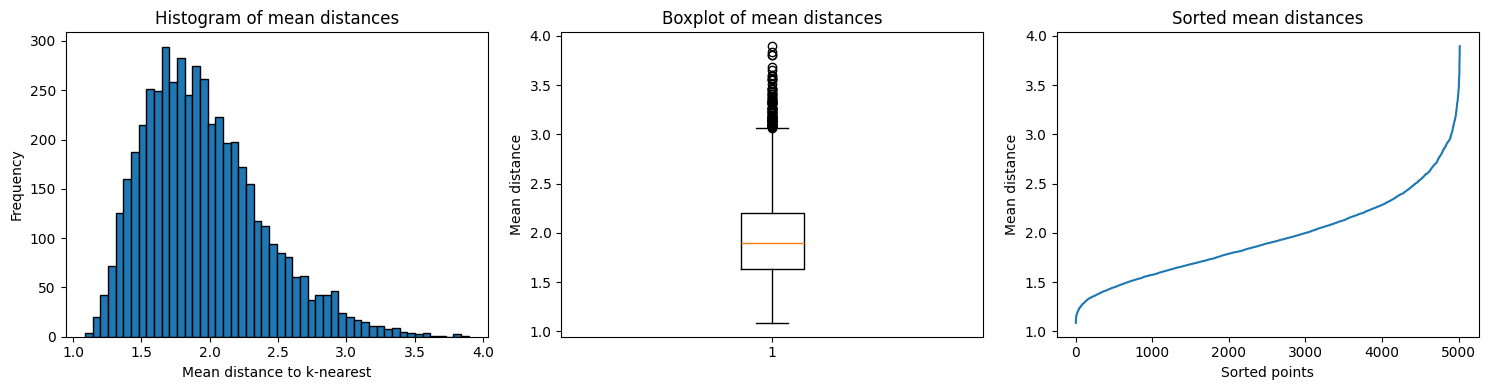

Complete metrics for the dataset:
mean_global_distance: 4.746041764549954
bounding_box_volume: 573224814.1056615
geometric_density: 8.750493482781102e-06
mean_k_distance: 1.9555382650885467
k_distance_percentiles: {10: np.float64(1.3711926930058456), 50: np.float64(1.9543005199377115), 90: np.float64(2.6952921359139634)}
mean_per_point: 1.955538265088547
std_per_point: 0.43531748243056084
variation_coefficient: 0.23232267673567022
min_distance_per_point: 1.0868139601108435
max_distance_per_point: 3.896623586945456
max_min_ratio: 3.5853639444859926


In [56]:
metrics = dataset_analysis(X, k=k_elbow)
print("Complete metrics for the dataset:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Overall, the dataset exhibits moderate sparsity in the standardized feature space, as indicated by the relatively high _mean global distance_ and the low _geometric density_. The $k$-nearest-neighbor analysis reveals a fairly compact distribution of local distances, with a _mean k-distance_ close to 2.0 and a limited spread, as confirmed by the low _coefficient of variation_. This suggests that most data points share a comparable local neighborhood density, with only a limited number of highly isolated observations.

At the same time, the noticeable gap between lower and upper k-distance percentiles, together with a max-to-min distance ratio greater than 3, indicates the presence of both dense regions and more dispersed points. This combination suggests that the dataset is a reasonable candidate for DBSCAN, although careful tuning of the $\epsilon$ parameter will be required to balance cluster detection and noise identification.

---

## DBSCAN with the Elbow Method

To select an appropriate value for the $\epsilon$ parameter, we apply the elbow method to the sorted $k$-nearest-neighbor distance curve. The elbow point is automatically detected using the `KneeLocator` function, which identifies the location where the rate of increase in distances changes most significantly.

The value of `eps` corresponding to this elbow is then used to run the DBSCAN algorithm. Finally, we analyze the resulting clustering configuration by inspecting the number of clusters identified by the algorithm, as well as the proportion of points classified as noise.

In [57]:
def elbow_method(df, k=2, curve: str = 'convex'):
    nn = NearestNeighbors(n_neighbors=k).fit(df)
    distances, _ = nn.kneighbors(df)
    kth_distances = np.sort(distances[:, k - 1])

    # Find the knee of the curve using KneeLocator
    kneedle = KneeLocator(range(len(kth_distances)), kth_distances, curve=curve, direction="increasing")
    knee_index = kneedle.knee
    knee_value = kneedle.knee_y

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=np.arange(len(kth_distances)), y=kth_distances, label=f'{k}-NN Distance', color="blue")
    plt.axvline(x=knee_index, color="red", linestyle="--", label=f"Knee Point ({knee_value:.2f})")
    plt.xlabel("Point Index (sorted by distance)", fontsize=12)
    plt.ylabel("Distance to k-th Nearest Neighbor", fontsize=12)
    plt.title(f"Distances to {k}-Nearest Neighbor", fontsize=14)
    plt.legend()
    plt.show()

    return knee_value

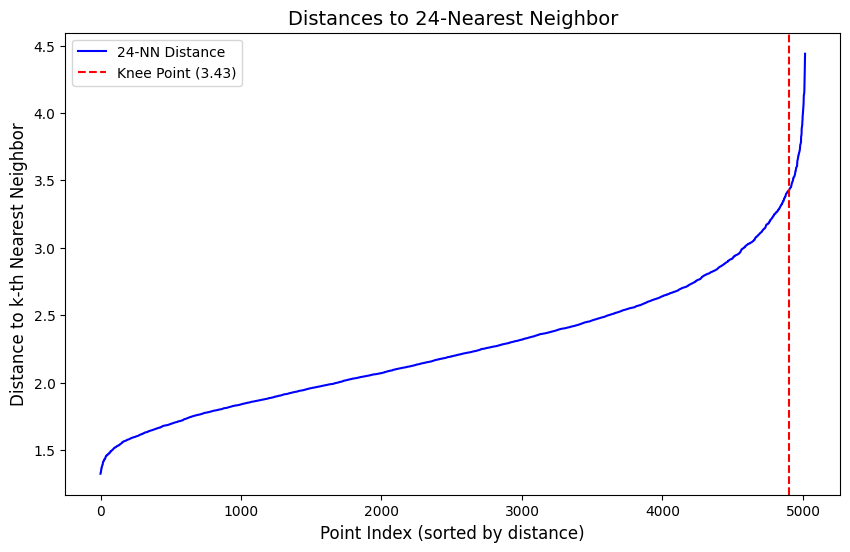

In [58]:
best_eps = elbow_method(X, k=k_elbow)

In [59]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=k_elbow,
    metric='euclidean'
)
clusters = dbscan.fit_predict(X)



unique_labels = set(clusters)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(clusters).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers (noise): {n_noise} ({n_noise/len(clusters)*100:.1f}%)")
print(f"Points per cluster:")
for label in sorted(unique_labels):
    count = list(clusters).count(label)
    if label == -1:
        print(f"  Noise: {count} points ({count/len(clusters)*100:.1f}%)")
    else:
        print(f"  Cluster {label}: {count} points ({count/len(clusters)*100:.1f}%)")

Number of clusters found: 1
Number of outliers (noise): 1 (0.0%)
Points per cluster:
  Noise: 1 points (0.0%)
  Cluster 0: 5015 points (100.0%)


---

## Grid Search for DBSCAN Parameter Selection

Since the elbow method resulted in a single large cluster, we adopt a more heuristic approach by performing a grid search over the DBSCAN parameters.

We begin by plotting the k-distance curves for two representative values of $k$. These plots help visualize how neighborhood distances evolve as $k$ increases and provide guidance for defining a reasonable search space for the $\epsilon$ parameter.

Based on these curves, we compute the $1st$ and $95th$ percentiles of the k-distance distribution and use them as approximate lower and upper bounds for $\epsilon$. This choice ensures that the values explored during the grid search cover the range of typical neighborhood distances, while limiting the influence of extreme outliers.

The resulting grid search allows us to systematically explore different combinations of $\epsilon$ and _min_samples_, in order to identify configurations that yield meaningful cluster structures.

In [60]:
def plot_k_distance(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)
    distances, indices = neighbors.kneighbors(X)

    # sorting distances from k-nearest
    k_distances = np.sort(distances[:, k-1])

    # Finding a range for epsilon
    eps_min = np.percentile(k_distances, 1)
    eps_max = np.percentile(k_distances, 95)

    plt.figure(figsize=(8,4))
    plt.plot(k_distances)
    plt.axhline(y=eps_min, color='red', linestyle='--', label=f"eps_min = {eps_min:.2f}")
    plt.axhline(y=eps_max, color='orange', linestyle='--', label=f"eps_max = {eps_max:.2f}")
    plt.title(f"K-distance plot (k={k})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel("Distance to k-th nearest neighbor")
    plt.grid(True)
    plt.show()

    return eps_min, eps_max

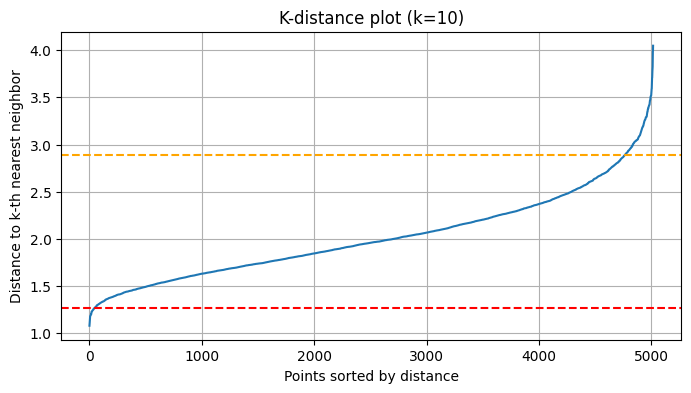

k=10| epsilon_min: 1.2722029446843617, epsilon_max: 2.8872399145714187


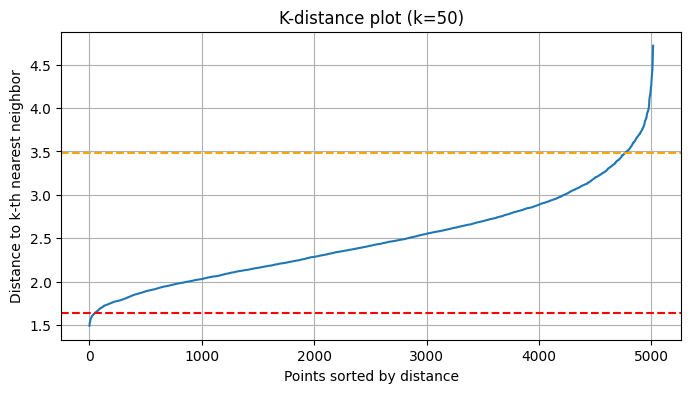

k=50| epsilon_min: 1.6383070501236516, epsilon_max: 3.4822945948279784


In [61]:
kmin = 10
kmax = 50

eps_min, eps_max = plot_k_distance(X, k=kmin)
print(f"k={kmin}| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

eps_min, eps_max = plot_k_distance(X, k=kmax)
print(f"k={kmax}| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

In [62]:
def grid_search(X, min_samples, eps_values, top_n=10):
    all_results = []
    
    for k in min_samples:
        for eps in eps_values:
            dbscan = DBSCAN(eps=eps, min_samples=k, metric='euclidean')
            clusters = dbscan.fit_predict(X)
            n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
            n_noise = (clusters == -1).sum()
            noise_pct = n_noise / len(clusters) * 100
            
            if 2 <= n_clusters <= 10 and noise_pct < 40:
                unique, counts = np.unique(clusters, return_counts=True)
                non_noise_mask_idx = unique != -1
                non_noise_counts = counts[non_noise_mask_idx]
                
                if len(non_noise_counts) > 0 and np.all(non_noise_counts >= 30):
                    non_noise_mask = clusters != -1
                    sil = -1
                    if non_noise_mask.sum() >= 2:
                        try:
                            sil = silhouette_score(X[non_noise_mask], clusters[non_noise_mask])
                        except:
                            sil = -1
                    
                    all_results.append((eps, k, n_clusters, n_noise, sil))
    
    all_results.sort(key=lambda t: (-t[2], t[3], -t[4]), reverse=False)
    
    results = all_results[:top_n]
    
    for eps, k, n_clusters, n_noise, sil in results:
        print(f"eps={eps:.3f}, min_samples={k}, clusters={n_clusters}, "
              f"noise={n_noise}, silhouette={sil:.3f}")
    
    return results

In [63]:
eps_values = np.linspace(1.5, 3.0, 30)
min_samples = list(range(kmin, kmax))

results = grid_search(X, min_samples, eps_values, top_n=10)

eps=2.328, min_samples=48, clusters=2, noise=795, silhouette=0.178
eps=2.328, min_samples=49, clusters=2, noise=814, silhouette=0.178
eps=2.276, min_samples=43, clusters=2, noise=889, silhouette=0.183
eps=2.276, min_samples=44, clusters=2, noise=899, silhouette=0.184
eps=2.276, min_samples=45, clusters=2, noise=913, silhouette=0.181
eps=2.276, min_samples=46, clusters=2, noise=924, silhouette=0.181
eps=2.276, min_samples=47, clusters=2, noise=947, silhouette=0.184
eps=2.276, min_samples=48, clusters=2, noise=956, silhouette=0.184
eps=2.276, min_samples=49, clusters=2, noise=964, silhouette=0.185
eps=2.224, min_samples=39, clusters=2, noise=992, silhouette=0.186


In [64]:
if results:
    eps_best, k_best, _, _, _ = results[0]

    dbscan = DBSCAN(
        eps=eps_best,
        min_samples=k_best,
        metric='euclidean'
    )
    clusters = dbscan.fit_predict(X)

    print(f"Best combination: eps={eps_best}, min_samples={k_best}")
else:
    print("No combination satisfies the criteria.")



unique_labels = set(clusters)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(clusters).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers (noise): {n_noise} ({n_noise/len(clusters)*100:.1f}%)")
print(f"Points per cluster:")
for label in sorted(unique_labels):
    count = list(clusters).count(label)
    if label == -1:
        print(f"  Noise: {count} points ({count/len(clusters)*100:.1f}%)")
    else:
        print(f"  Cluster {label}: {count} points ({count/len(clusters)*100:.1f}%)")

Best combination: eps=2.3275862068965516, min_samples=48
Number of clusters found: 2
Number of outliers (noise): 795 (15.8%)
Points per cluster:
  Noise: 795 points (15.8%)
  Cluster 0: 4137 points (82.5%)
  Cluster 1: 84 points (1.7%)


---

## Clustering Validity

Although the resulting clustering exhibits two clusters with very different sizes, suggesting that this approach may not be fully effective, we still evaluate the DBSCAN results using two complementary validation metrics: the **silhouette score** and the **S_Dbw index**.

The silhouette score assesses cluster separation and compactness based on distances, with higher values indicating better-defined clusters. The S_Dbw index, instead, evaluates clustering quality in terms of density and variance, with lower values corresponding to more compact and well-separated clusters.

Taken together, these metrics provide a more comprehensive validation of the clustering results: while the silhouette score captures distance based separation, the S_Dbw index focuses on density related properties that are more closely aligned with DBSCAN’s density-based nature.

In [65]:
mask = clusters != -1
X_no_noise = X[mask]
clusters_no_noise = clusters[mask]

# Silhouette Score
if len(set(clusters_no_noise)) > 1:
    sil = silhouette_score(X_no_noise, clusters_no_noise)
else:
    sil = np.nan

print(f"Silhouette Score: {sil}\n   BEST: 1")


# S-Dwb Index
if len(np.unique(clusters_no_noise)) > 1:
    sdbw = S_Dbw(X_no_noise, clusters_no_noise)
else:
    sdbw = np.nan

print(f"S_Dbw Index: {sdbw}\n    BEST: 0")

Silhouette Score: 0.1783626426930143
   BEST: 1
S_Dbw Index: 0.6596835702403058
    BEST: 0


---

## Clustering Visualization

To gain a clearer understanding of the clustering structure produced by DBSCAN, we visualize the results using dimensionality reduction techniques. In particular, we project the high-dimensional data into a two-dimensional space using **PCA**, **t-SNE**, and **UMAP**.

These visualizations allow us to qualitatively assess cluster separation, overlap, and the presence of noise points, providing complementary perspectives on the structure uncovered by the density-based clustering.

In [66]:
unique_clusters = np.unique(clusters)

# Cluster-color ditionary
palette = sns.color_palette("viridis", len(unique_clusters))
color_map = {cl: palette[i] for i, cl in enumerate(unique_clusters)}

colors = [color_map[c] for c in clusters]

def PCA_visualization():
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, s=40)

    for cl in unique_clusters:
        plt.scatter([], [], color=color_map[cl], label=f"Cluster {cl}")

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )
    plt.title("PCA Visualization for DBSCAN")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()
    
    return

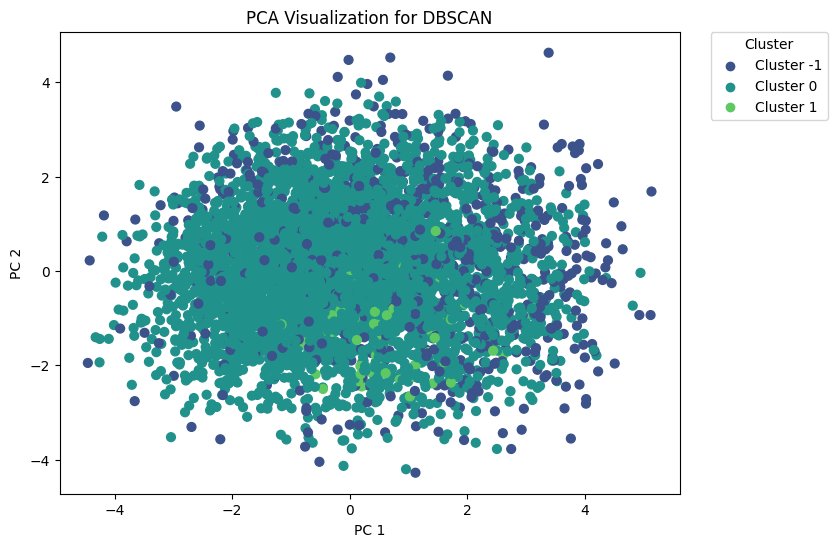

In [67]:
PCA_visualization()

In [68]:
def TSNE_visualization():
    tsne = TSNE(
        n_components=2,
        perplexity=10,
        early_exaggeration=30,
        learning_rate='auto',
        init='pca',
        random_state=42
    )

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=colors,
        s=40,
        alpha=0.8
    )

    for cl in unique_clusters:
        plt.scatter([], [], color=color_map[cl], label=f"Cluster {cl}")

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )

    plt.title("t-SNE Visualization for DBSCAN")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

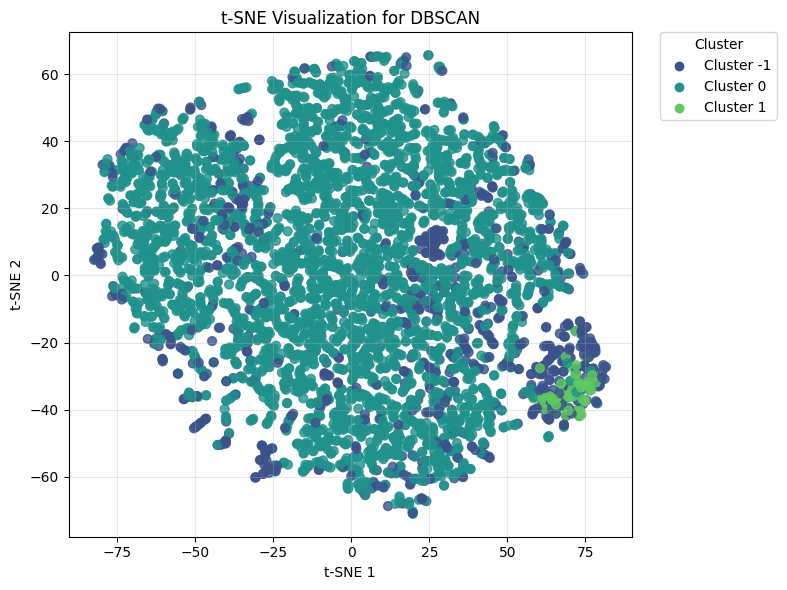

In [69]:
TSNE_visualization()

In [70]:
def UMAP_visualization():
    reducer = umap.UMAP(
        n_neighbors=40,
        min_dist=0.0,
        metric='euclidean',
        n_jobs=1
    )

    X_umap = reducer.fit_transform(X)

    df_vis = pd.DataFrame({
        "UMAP1": X_umap[:,0],
        "UMAP2": X_umap[:,1],
        "cluster": clusters
    })

    ordered_palette = [color_map[cl] for cl in unique_clusters]

    plt.figure(figsize=(10,8))

    sns.scatterplot(data=df_vis, x="UMAP1", y="UMAP2", hue="cluster",
                    hue_order=unique_clusters, palette=ordered_palette,
                    s=20, linewidth=0, alpha=0.9)

    plt.title("UMAP Visualization for DBSCAN")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )

    plt.tight_layout()
    plt.show()

    return

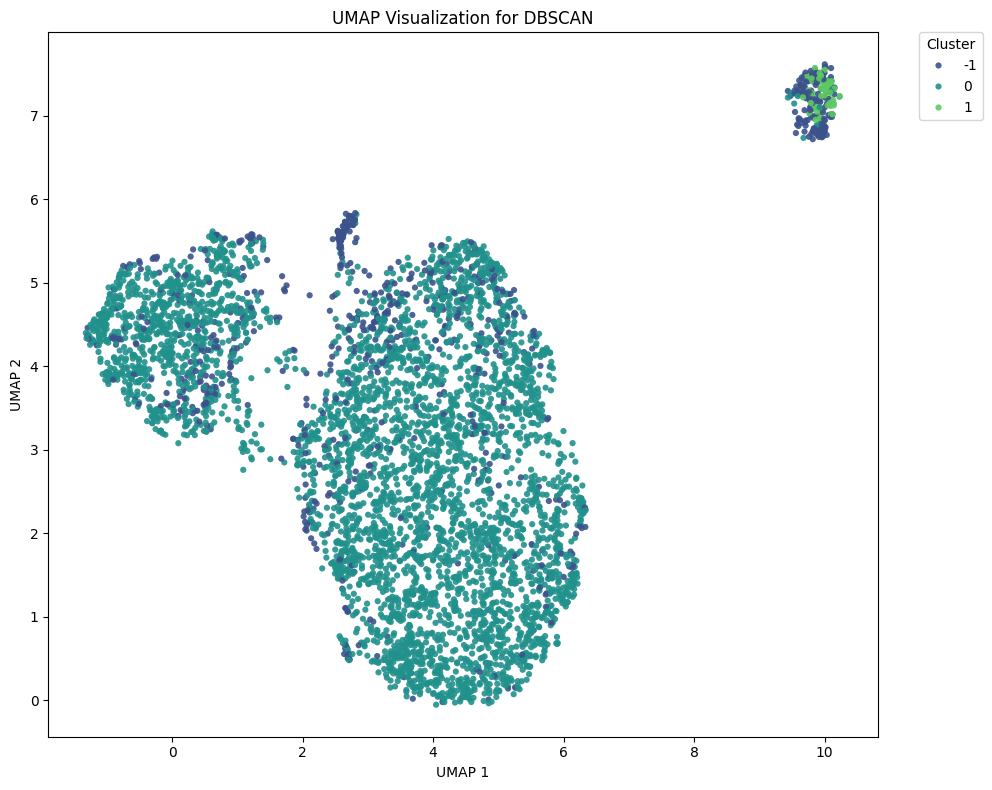

In [71]:
UMAP_visualization()

---
---

## Reducing Dataset Dimensionality

Since high dimensionality can significantly hinder the performance of DBSCAN, we reduce the dataset to a subset of three features that we consider the most relevant for capturing meaningful structure in the data.

After this dimensionality reduction, we repeat the entire analysis pipeline described above, including dataset distribution assessment, parameter selection, clustering execution, and evaluation, in order to verify whether a lower dimensional representation leads to improved DBSCAN performance.

In [72]:
df = df.copy()

selected_features = [
    "percussiveness",
    "harmonic_richness",
    "trap_index"
    ]

df_dbscan = df[selected_features]

print(f"New dataset shape: {df_dbscan.shape[0]} rows x {df_dbscan.shape[1]} columns")


New dataset shape: 5016 rows x 3 columns


In [73]:
scaler = StandardScaler()
X = scaler.fit_transform(df_dbscan)

---

### Dataset Analysis

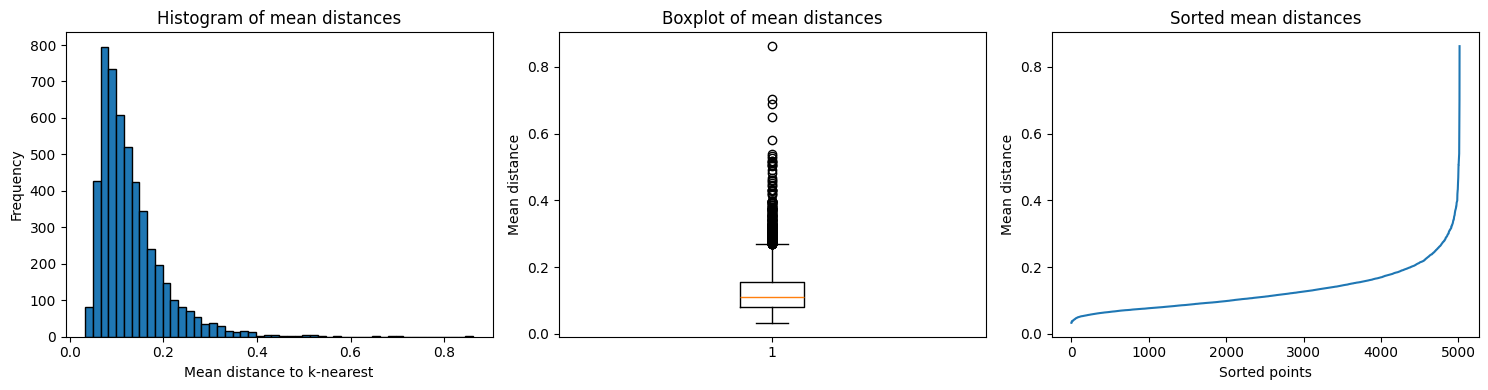

Complete metrics for the dataset:
mean_global_distance: 2.1898464514848306
bounding_box_volume: 112.71435368103707
geometric_density: 44.50187430603957
mean_k_distance: 0.1293328917937569
k_distance_percentiles: {10: np.float64(0.0), 50: np.float64(0.11577120058831435), 90: np.float64(0.25409288602286023)}
mean_per_point: 0.1293328917937569
std_per_point: 0.06952353285973936
variation_coefficient: 0.5207421983930155
min_distance_per_point: 0.03244168424940382
max_distance_per_point: 0.8622082068305659
max_min_ratio: 26.57717152420687


In [74]:
k_elbow = 2 * X.shape[1]

metrics = dataset_analysis(X, k=k_elbow)
print("Complete metrics for the dataset:")
for key, value in metrics.items():
    print(f"{key}: {value}")

After reducing the dataset to three dimensions, the data distribution changes substantially.

The _mean global distance_ decreases markedly, while the _bounding box volume_ is drastically reduced, resulting in a much higher geometric density. This indicates that data points are now concentrated in a more compact region of the feature space, a condition that is generally more favorable for density-based clustering algorithms such as DBSCAN.

The $k$-nearest-neighbor analysis reveals very small average neighborhood distances, with low median values and a clear separation between typical local distances and more isolated points. At the same time, the high max-to-min distance ratio suggests the coexistence of dense cores and sparse regions, potentially corresponding to noise or boundary points.

Overall, these characteristics indicate that the reduced dataset provides a more suitable setting for DBSCAN, with clearer density contrasts and a more interpretable neighborhood structure.

---

### DBSCAN with Elbow Method

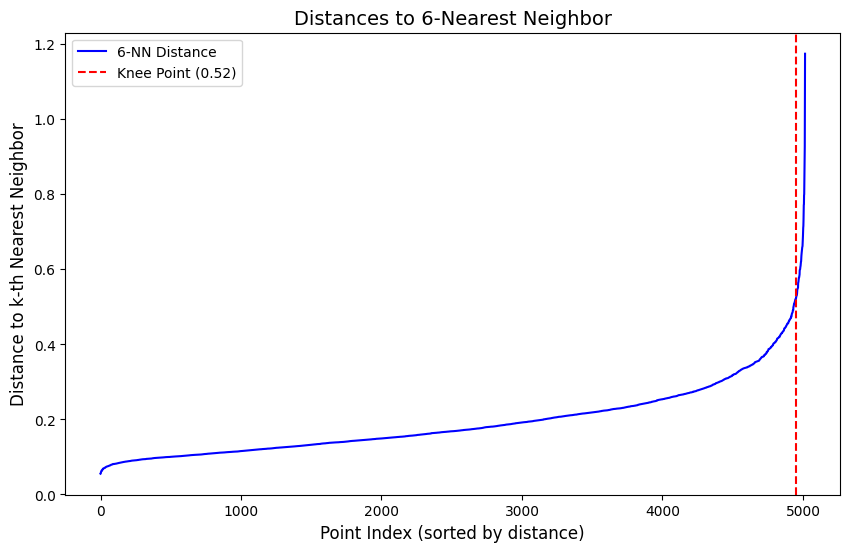

Number of clusters found: 1
Number of outliers (noise): 19 (0.4%)
Points per cluster:
  Noise: 19 points (0.4%)
  Cluster 0: 4997 points (99.6%)


In [75]:
best_eps = elbow_method(X, k=k_elbow)

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=k_elbow,
    metric='euclidean'
)
clusters = dbscan.fit_predict(X)



unique_labels = set(clusters)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(clusters).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers (noise): {n_noise} ({n_noise/len(clusters)*100:.1f}%)")
print(f"Points per cluster:")
for label in sorted(unique_labels):
    count = list(clusters).count(label)
    if label == -1:
        print(f"  Noise: {count} points ({count/len(clusters)*100:.1f}%)")
    else:
        print(f"  Cluster {label}: {count} points ({count/len(clusters)*100:.1f}%)")

---

### Grid Search for DBSCAN Parameters

Since the elbow method still fails to produce a meaningful clustering, we perform the grid search procedure again on the reduced three-dimensional dataset.

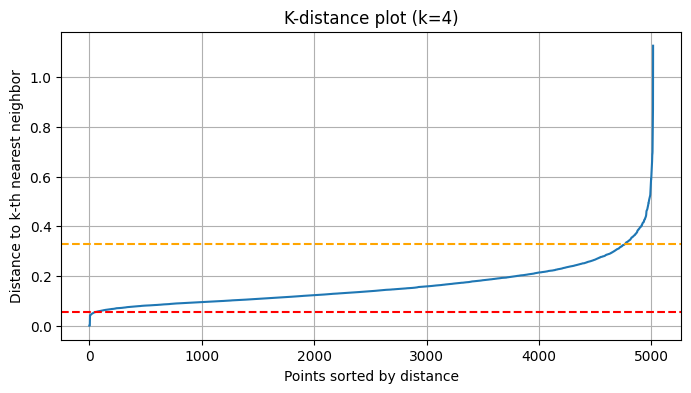

k=4| epsilon_min: 0.054449558693585205, epsilon_max: 0.32797997807981566


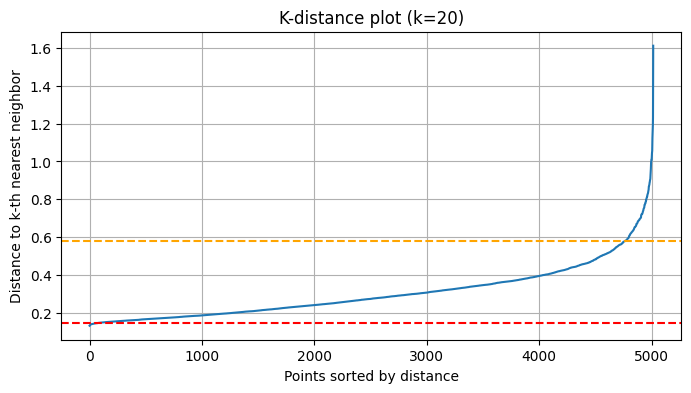

k=20| epsilon_min: 0.14303504564319303, epsilon_max: 0.5787482261863276


In [76]:
kmin = 4
kmax = 20

eps_min, eps_max = plot_k_distance(X, k=kmin)
print(f"k={kmin}| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

eps_min, eps_max = plot_k_distance(X, k=kmax)
print(f"k={kmax}| epsilon_min: {eps_min}, epsilon_max: {eps_max}")

In [77]:
eps_values = np.linspace(0.02, 0.6, 30)
min_samples = list(range(kmin, kmax))

results = grid_search(X, min_samples, eps_values, top_n=10)

eps=0.260, min_samples=18, clusters=3, noise=1774, silhouette=0.317
eps=0.300, min_samples=14, clusters=2, noise=838, silhouette=0.154
eps=0.320, min_samples=18, clusters=2, noise=888, silhouette=0.166
eps=0.300, min_samples=15, clusters=2, noise=916, silhouette=0.161
eps=0.300, min_samples=16, clusters=2, noise=991, silhouette=0.179


In [78]:
if results:
    eps_best, k_best, _, _, _ = results[0]

    dbscan = DBSCAN(
        eps=eps_best,
        min_samples=k_best,
        metric='euclidean'
    )
    clusters = dbscan.fit_predict(X)

    print(f"Best combination: eps={eps_best}, min_samples={k_best}")
else:
    print("No combination satisfies the criteria.")

Best combination: eps=0.25999999999999995, min_samples=18


In [79]:
labels = np.array(clusters)
unique_labels = sorted(set(labels))
total_points = len(labels)

counts = {l: np.sum(labels == l) for l in unique_labels}
percentages = {l: (counts[l] / total_points) * 100 for l in unique_labels}

n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = counts.get(-1, 0)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers (noise): {n_noise} ({percentages.get(-1, 0):.1f}%)")
print("Points per cluster:")

for l in unique_labels:
    name = "Noise" if l == -1 else f"Cluster {l}"
    print(f"  {name}: {counts[l]} points ({percentages[l]:.1f}%)")

Number of clusters found: 3
Number of outliers (noise): 1774 (35.4%)
Points per cluster:
  Noise: 1774 points (35.4%)
  Cluster 0: 3054 points (60.9%)
  Cluster 1: 100 points (2.0%)
  Cluster 2: 88 points (1.8%)


In [80]:
def cluster_sizes():
    labels = list(counts.keys())
    sizes = [counts[l] for l in labels]

    labels_str = ["Noise" if l == -1 else f"Cluster {l}" for l in labels]
    colors = ["lightgray" if l == -1 else "cornflowerblue" for l in labels]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels_str, sizes, color=colors, edgecolor="black")

    plt.title("Cluster size distribution")
    plt.ylabel("Number of points")
    plt.xlabel("Cluster")
    plt.grid(axis="y", alpha=0.3)

    for bar, l in zip(bars, labels):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sizes) * 0.01,
            f"{percentages[l]:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

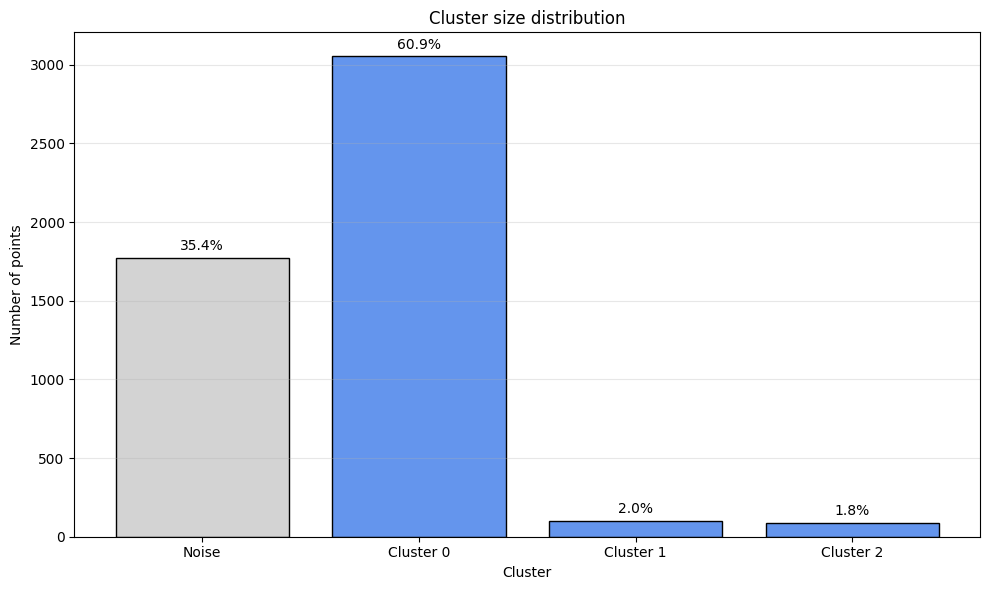

In [81]:
cluster_sizes()

---

### Cluster validity and visualization

In [82]:
mask = clusters != -1
X_no_noise = X[mask]
clusters_no_noise = clusters[mask]

# Silhouette Score
if len(set(clusters_no_noise)) > 1:
    sil = silhouette_score(X_no_noise, clusters_no_noise)
else:
    sil = np.nan

print(f"Silhouette Score: {sil}\n   BEST: 1")

print("\n")

# S-Dwb Index
if len(np.unique(clusters_no_noise)) > 1:
    sdbw = S_Dbw(X_no_noise, clusters_no_noise)
else:
    sdbw = np.nan

print(f"S_Dbw Index: {sdbw}\n    BEST: 0")

Silhouette Score: 0.3170978728693942
   BEST: 1


S_Dbw Index: 0.3473863368279458
    BEST: 0


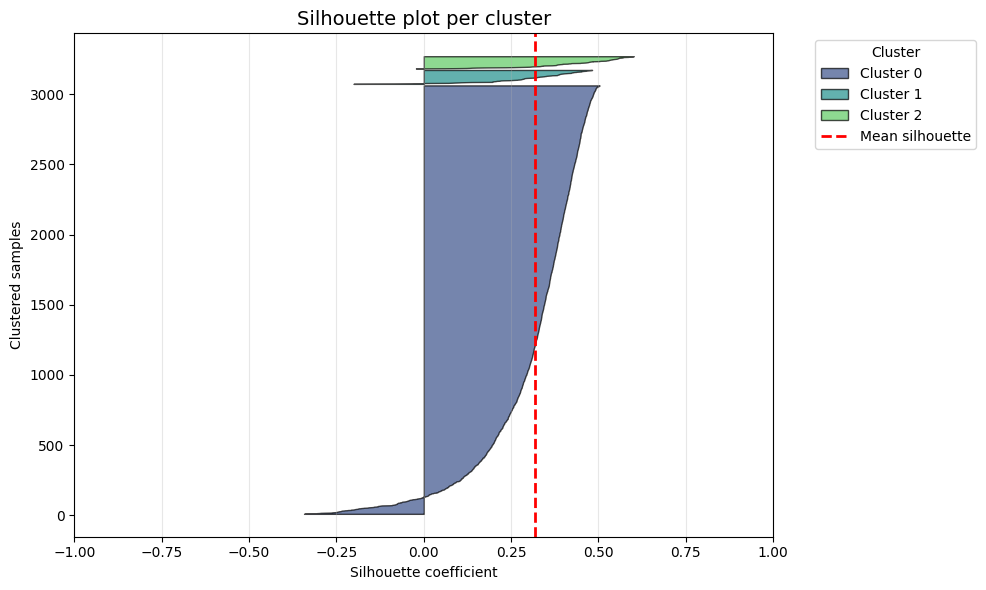

In [83]:
silhouette_vals = silhouette_samples(X_no_noise, clusters_no_noise)

clusters_present = sorted(np.unique(clusters_no_noise))

palette = sns.color_palette("viridis", len(clusters_present))
color_map_sil = {cl: palette[i] for i, cl in enumerate(clusters_present)}

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for cl in clusters_present:
    cl_sil_vals = silhouette_vals[clusters_no_noise == cl]
    cl_sil_vals.sort()

    size_cl = cl_sil_vals.shape[0]
    y_upper = y_lower + size_cl

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cl_sil_vals,
        facecolor=color_map_sil[cl],
        edgecolor="black",
        alpha=0.7,
        label=f"Cluster {cl}"
    )

    y_lower = y_upper + 10

ax.axvline(
    sil,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean silhouette"
)

ax.set_title("Silhouette plot per cluster", fontsize=14)
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Clustered samples")
ax.set_xlim([-1, 1])

ax.grid(True, axis="x", alpha=0.3)

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [84]:
unique_clusters = np.unique(labels)

palette = sns.color_palette("viridis", len(unique_clusters))
color_map = dict(zip(unique_clusters, palette))
colors = [color_map[c] for c in labels]

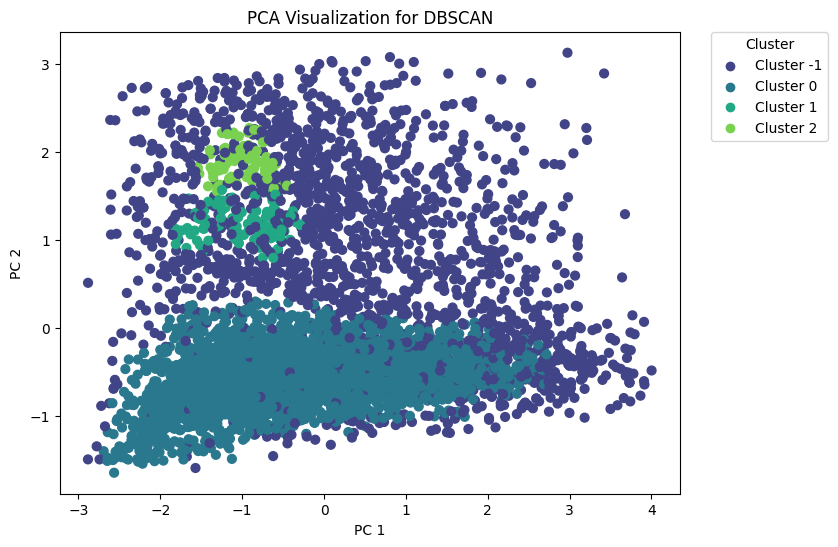

In [85]:
PCA_visualization()

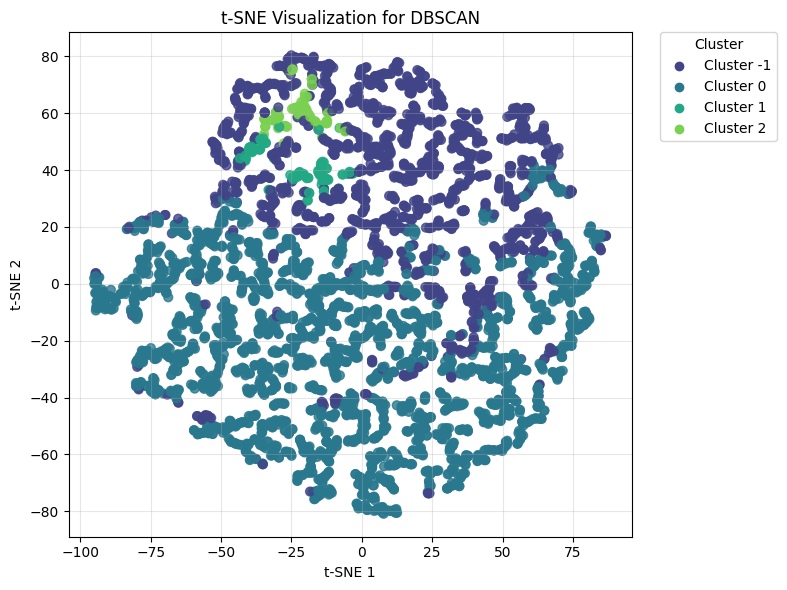

In [86]:
TSNE_visualization()

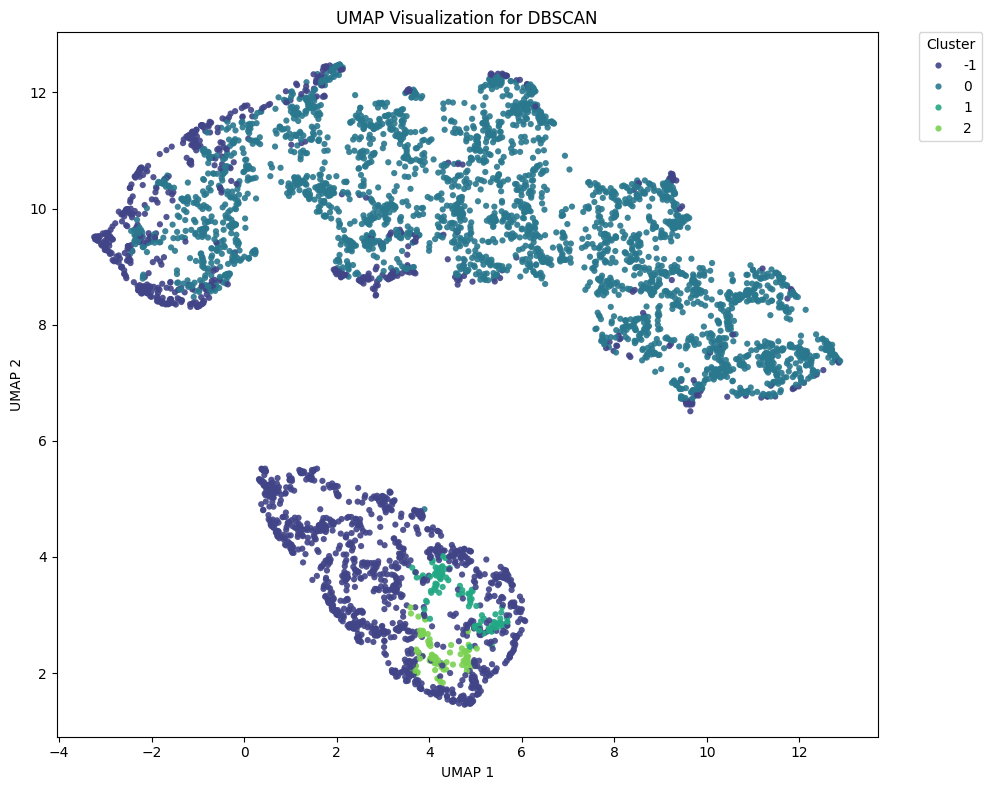

In [87]:
UMAP_visualization()

In [88]:
def boxplot_cluster(df_dbscan, labels, color_map):
    df_plot = df_dbscan.copy()
    df_plot["cluster"] = labels.astype(int)

    # Removing noise
    df_plot = df_plot[df_plot["cluster"] != -1]

    # Numerical features
    numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("cluster")

    # Global Z-score
    scaler = StandardScaler()
    df_plot[numeric_cols] = scaler.fit_transform(df_plot[numeric_cols])

    # Long format
    df_long = df_plot.melt(
        id_vars="cluster",
        value_vars=numeric_cols,
        var_name="feature",
        value_name="z_score"
    )

    cluster_order = sorted(df_plot["cluster"].unique())

    palette = {cl: color_map[cl] for cl in cluster_order}

    g = sns.catplot(
        data=df_long,
        x="cluster",
        y="z_score",
        hue="cluster",
        col="feature",
        col_wrap=3,
        kind="box",
        order=cluster_order,
        palette=palette,
        sharey=True,
        height=4,
        aspect=1,
        legend=False
    )

    g.fig.subplots_adjust(top=0.86)
    g.fig.suptitle(
        "Cluster characterization – Feature distributions (Z-score)",
        #fontsize=16
    )

    for ax in g.axes.flatten():
        ax.axhline(0, color="red", linestyle="--", alpha=0.6)
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Z-score")

    plt.show()

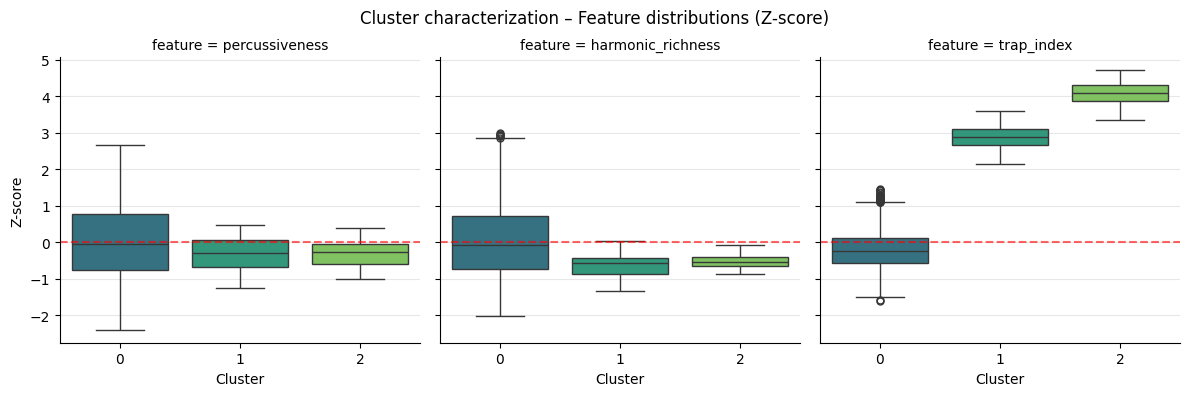

In [89]:
boxplot_cluster(df_dbscan, labels, color_map)